In [1]:
%load_ext autoreload
%autoreload 2
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.76:40932 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.76:40932,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
def get_latitude_average(ds, lats, grid, add_depth=False, depth_name="depth"):        
    Z_l = grid.axes["Z"].coords["center"]

    lat = xr.DataArray(lats, dims="lat", coords={"lat": lats}).chunk({"lat": 1})

    wet = ds["wet"].fillna(0.0)
    area = ds["areacello"].fillna(0.0)
    thk = ds["thkcello"].fillna(0.0)

    mask_south_yq = ds["geolat_v"] <= lat
    boundary_mask_yh = grid.diff(mask_south_yq.astype(float), axis="Y", boundary="fill") < 0
    valid_bnd = boundary_mask_yh & (wet > 0.0)

    layer_area = (area * thk).where(valid_bnd)
    tot_layer_area = layer_area.sum(dim=["xh", "yh"], skipna=True)

    vars_on_yh = [
        v for v in ds.data_vars
        if v != "thkcello" and {"xh", "yh"}.issubset(ds[v].dims)
    ]
    ds_var = ds[vars_on_yh]

    var_integrated = (ds_var * layer_area).sum(dim=["xh", "yh"], skipna=True)
    ds_avg = var_integrated / tot_layer_area.where(tot_layer_area > 0)

    if add_depth:
        z = check_depth_sign(approximate_z_top_down(ds, dim=f"{Z_l}"))
        z_weighted = (z.where(valid_bnd) * layer_area).sum(dim=["xh", "yh"], skipna=True)
        z_avg = z_weighted / tot_layer_area.where(tot_layer_area > 0)
        ds_avg = ds_avg.assign_coords({depth_name: z_avg})

    ds_avg = ds_avg.assign_coords(lat=("lat", lats))
    return ds_avg

In [4]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

In [5]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds

native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]

ds_ctrl= xr.open_mfdataset(full_depth_files[0], 
                            data_vars="minimal",
                            coords="minimal",
                            compat="override",
                           parallel=True, 
                           preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:],                             
                              data_vars="minimal",
                            coords="minimal",
                            compat="override",
                              parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")
ds.coords["z_i"] = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])

ds["depth"] = approximate_z_top_down(ds.chunk({"z_l": -1, "year":1, "expt":1, "xh":-1, "yh":-1}), dim="z")
ds.coords["depth_i"] = np.sort(np.insert(-ds.coords["z_i"].values, 0, -7.000e+03, axis=0)) #make sure that coordinates are ordered from greatest to least. could also do np.sort 
ds.coords["depth_l"] = np.sort(np.insert(-ds.coords["z_l"].values, 0, -6875.0, axis=0))

ds = ds.chunk({"z_l": -1, "year":1, "xh":-1, "yh":-1, "expt":1})

In [6]:
grid = CM4Xutils.ds_to_grid(ds, Zprefix = "z_")
ds_on_z = CM4Xutils.remap_vertical_coord("depth", grid._ds, grid)
ds_on_z

<xarray.Dataset> Size: 488GB
Dimensions:         (xh: 720, xq: 721, yh: 560, yq: 561, year: 350, expt: 2,
                     depth_i: 37, depth_l: 36)
Coordinates: (12/25)
  * xh              (xh) int64 6kB 0 1 2 3 4 5 6 ... 713 714 715 716 717 718 719
  * xq              (xq) int64 6kB 0 1 2 3 4 5 6 ... 714 715 716 717 718 719 720
  * yh              (yh) int64 4kB 0 1 2 3 4 5 6 ... 553 554 555 556 557 558 559
  * yq              (yq) int64 4kB 0 1 2 3 4 5 6 ... 554 555 556 557 558 559 560
  * year            (year) int64 3kB 1850 1851 1852 1853 ... 2196 2197 2198 2199
  * expt            (expt) object 16B 'control' 'forced'
    ...              ...
    geolon_v        (yq, xh) float64 3MB dask.array<chunksize=(561, 720), meta=np.ndarray>
    lat             (yh, xh) float64 3MB dask.array<chunksize=(560, 720), meta=np.ndarray>
    lon             (yh, xh) float64 3MB dask.array<chunksize=(560, 720), meta=np.ndarray>
    wet             (yh, xh) float32 2MB dask.array<chunksize=(560, 720), meta=np.ndarray>
    wet_u           (yh, xq) float32 2MB dask.array<chunksize=(560, 721), meta=np.ndarray>
    wet_v           (yq, xh) float32 2MB dask.array<chunksize=(561, 720), meta=np.ndarray>
Data variables:
    thkcello        (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    cfc11           (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    cfc12           (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    sf6             (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    sigma2          (expt, year, yh, xh, depth_l) float64 81GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    sigma2_offline  (expt, year, yh, xh, depth_l) float64 81GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    so              (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    thetao          (expt, year, yh, xh, depth_l) float32 41GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
    volcello        (expt, year, yh, xh, depth_l) float64 81GB dask.array<chunksize=(1, 1, 560, 720, 36), meta=np.ndarray>
Attributes:
    filename:            ocean_inert_z.044601-045012.cfc11.nc
    title:               CM4_piControl_c192_OM4p125_v8
    associated_files:    areacello: 04460101.ocean_static.nc
    grid_type:           regular
    grid_tile:           N/A
    external_variables:  volcello areacello
    provenance:          Diagnostics have been conservatively remapped into m...

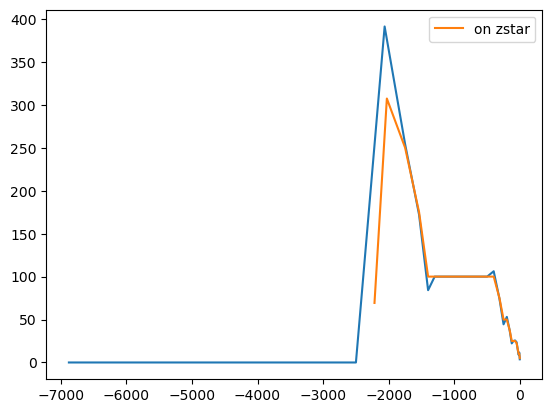

In [7]:
plt.plot(ds_on_z.depth_l, ds_on_z["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["depth"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200), label = "on zstar")
plt.legend()

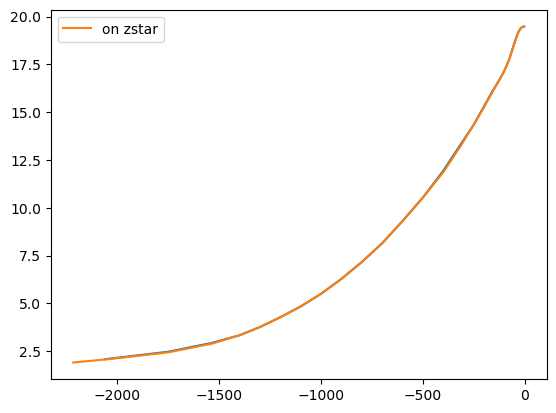

In [8]:
plt.plot(ds_on_z.depth_l, ds_on_z["thetao"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["depth"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["thetao"].isel(year = 0, expt = 0, yh = 200, xh = 200), label = "on zstar")
plt.legend()

In [ ]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes

grid = CM4Xutils.ds_to_grid(ds_on_z.rename({"depth_l": "zl", "depth_i": "zi"}), Zprefix="z")

codes = generate_basin_codes(grid._ds, lon="geolon", lat="geolat", persian=True, style="cmip6")
c_mask = codes.isin([1, 3, 5, 10, 11]).where(grid._ds.wet > 0.0)

ds = grid._ds.copy()
for v in ["thkcello", "wet"]:
    ds[v] = ds[v].where(c_mask > 0.0)

lats = np.arange(-75, 60, 1)
# import dask 
# with dask.config.set(**{'array.slicing.split_large_chunks': False}):
ds_zon_ts_ds = get_latitude_average(ds, lats, grid).chunk({"lat": 1, "year":1}).compute()

Task exception was never retrieved
future: <Task finished name='Task-30179' coro=<Client._gather.<locals>.wait() done, defined at /vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/distributed/client.py:2388> exception=AllExit()>
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/distributed/client.py", line 2397, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-30175' coro=<Client._gather.<locals>.wait() done, defined at /vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/distributed/client.py:2388> exception=AllExit()>
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/distributed/client.py", line 2397, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never

In [ ]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"IndoPac_Tracer_Avg_on_z.zarr"
ds_zon_ts_ds.to_zarr(savename, mode = "w")